In [1]:

import random
from collections import Counter

def hat_process_random(n: int, seed: int | None = None) -> int:

    rng = random.Random(seed)
    hat = list(range(1, n + 1))

    while len(hat) > 1:
        i, j = rng.sample(range(len(hat)), 2)
        a, b = hat[i], hat[j]
        for idx in sorted((i, j), reverse=True):
            hat.pop(idx)
        hat.append(abs(a - b))

    return hat[0]

def run_trials(n: int, trials: int = 2000, seed: int = 0):
    rng = random.Random(seed)
    counts = Counter()
    odd_count = 0

    for t in range(trials):
        final_val = hat_process_random(n, seed=rng.randrange(10**18))
        counts[final_val] += 1
        odd_count += (final_val % 2)

    print(f"n={n}, trials={trials}")
    print(f"Odd finals: {odd_count}/{trials} = {odd_count/trials:.4f}")
    for val, c in counts.most_common(10):
        print(f"{val:4d}: {c}")

if __name__ == "__main__":
    run_trials(2026, trials=2000, seed=1)


n=2026, trials=2000
Odd finals: 2000/2000 = 1.0000
  97: 17
  81: 16
  19: 15
 115: 13
  11: 13
  21: 13
   7: 13
  71: 13
  85: 13
 119: 13


In [2]:

from typing import List, Tuple

def step_once_state(hat: List[int], i: int, j: int) -> Tuple[List[int], int, int, int]:
    if i == j:
        raise ValueError("i and j must be different.")
    if not (0 <= i < len(hat) and 0 <= j < len(hat)):
        raise IndexError("Index out of range.")

    a, b = hat[i], hat[j]
    diff = abs(a - b)

    new_hat = hat[:]
    for idx in sorted((i, j), reverse=True):
        new_hat.pop(idx)
    new_hat.append(diff)
    return new_hat, a, b, diff

def parity_invariant_holds(initial_hat: List[int], steps: int = 1000, seed: int = 0) -> None:

    rng = random.Random(seed)
    hat = initial_hat[:]

    initial_parity = sum(hat) % 2
    initial_max = max(hat)

    for _ in range(min(steps, len(hat) - 1)):
        i, j = rng.sample(range(len(hat)), 2)
        hat, a, b, diff = step_once_state(hat, i, j)

        assert sum(hat) % 2 == initial_parity, "Sum parity changed!"
        assert max(hat) <= initial_max, "Max increased!"

    print("Checks passed: sum parity invariant; max never increases.")

if __name__ == "__main__":
    parity_invariant_holds(list(range(1, 2026 + 1)), steps=5000, seed=42)
    print("Initial sum parity for 1..2026 =", sum(range(1, 2026 + 1)) % 2)


Checks passed: sum parity invariant; max never increases.
Initial sum parity for 1..2026 = 1


In [ ]:


from functools import lru_cache
from itertools import combinations

def canonical_multiset(state: Tuple[int, ...]) -> Tuple[int, ...]:
    return tuple(sorted(state))

@lru_cache(maxsize=None)
def reachable_finals(state: Tuple[int, ...]) -> frozenset[int]:

    state = canonical_multiset(state)
    if len(state) == 1:
        return frozenset([state[0]])

    finals = set()
    for i, j in combinations(range(len(state)), 2):
        a, b = state[i], state[j]
        diff = abs(a - b)
        next_list = list(state)
        for idx in sorted((i, j), reverse=True):
            next_list.pop(idx)
        next_list.append(diff)
        finals |= set(reachable_finals(canonical_multiset(tuple(next_list))))

    return frozenset(finals)

def R_n(n: int) -> set[int]:
    """Compute R_n = reachable final values from {1,2,...,n} (small n only)."""
    return set(reachable_finals(canonical_multiset(tuple(range(1, n + 1)))))

def parity_allowed_set(n: int) -> set[int]:
    """The 'allowed-by-proof' set: correct parity and <= n."""
    target_parity = (n * (n + 1) // 2) % 2
    return {x for x in range(0, n + 1) if x % 2 == target_parity}

if __name__ == "__main__":
    for n in range(2, 21):
        reachable = R_n(n)
        allowed = parity_allowed_set(n)
        print(f"n={n:2d}  |R_n|={len(reachable):2d}  R_n={sorted(reachable)}")
        print(f"        allowed-by-parity={sorted(allowed)}")
        print(f"        matches allowed? {reachable == allowed}")


n= 2  |R_n|= 1  R_n=[1]
        allowed-by-parity=[1]
        matches allowed? True
n= 3  |R_n|= 2  R_n=[0, 2]
        allowed-by-parity=[0, 2]
        matches allowed? True
n= 4  |R_n|= 3  R_n=[0, 2, 4]
        allowed-by-parity=[0, 2, 4]
        matches allowed? True
n= 5  |R_n|= 3  R_n=[1, 3, 5]
        allowed-by-parity=[1, 3, 5]
        matches allowed? True
n= 6  |R_n|= 3  R_n=[1, 3, 5]
        allowed-by-parity=[1, 3, 5]
        matches allowed? True
n= 7  |R_n|= 4  R_n=[0, 2, 4, 6]
        allowed-by-parity=[0, 2, 4, 6]
        matches allowed? True
n= 8  |R_n|= 5  R_n=[0, 2, 4, 6, 8]
        allowed-by-parity=[0, 2, 4, 6, 8]
        matches allowed? True
n= 9  |R_n|= 5  R_n=[1, 3, 5, 7, 9]
        allowed-by-parity=[1, 3, 5, 7, 9]
        matches allowed? True
n=10  |R_n|= 5  R_n=[1, 3, 5, 7, 9]
        allowed-by-parity=[1, 3, 5, 7, 9]
        matches allowed? True
n=11  |R_n|= 6  R_n=[0, 2, 4, 6, 8, 10]
        allowed-by-parity=[0, 2, 4, 6, 8, 10]
        matches allowed? T

In [4]:

from collections import deque

def find_path_to_target(n: int, target: int, max_states: int = 300000):

    start = canonical_multiset(tuple(range(1, n + 1)))
    q = deque([start])
    parent = {start: None}
    move_taken = {start: None}

    visited = 1
    while q and visited <= max_states:
        state = q.popleft()
        if len(state) == 1 and state[0] == target:
            moves = []
            cur = state
            while parent[cur] is not None:
                moves.append(move_taken[cur])
                cur = parent[cur]
            moves.reverse()
            return moves


        for i, j in combinations(range(len(state)), 2):
            a, b = state[i], state[j]
            diff = abs(a - b)
            next_list = list(state)
            for idx in sorted((i, j), reverse=True):
                next_list.pop(idx)
            next_list.append(diff)
            nxt = canonical_multiset(tuple(next_list))

            if nxt not in parent:
                parent[nxt] = state
                move_taken[nxt] = (a, b, diff)
                q.append(nxt)
                visited += 1
                if visited > max_states:
                    break

    return None

def pretty_print_moves(n: int, moves: list[tuple[int,int,int]]):
    hat = list(range(1, n + 1))
    print("Start:", sorted(hat))
    for (a, b, diff) in moves:
        hat.remove(a)
        hat.remove(b)
        hat.append(diff)
        print(f"Pick ({a},{b}) -> {diff}   hat={sorted(hat)}")
    print("Final:", hat[0])

if __name__ == "__main__":
    n = 10
    target = 9
    moves = find_path_to_target(n, target, max_states=500000)
    if moves is None:
        print("No path found within limits.")
    else:
        print(f"Found path with {len(moves)} moves to reach final={target}.")
        pretty_print_moves(n, moves)


Found path with 9 moves to reach final=9.
Start: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Pick (1,2) -> 1   hat=[1, 3, 4, 5, 6, 7, 8, 9, 10]
Pick (1,3) -> 2   hat=[2, 4, 5, 6, 7, 8, 9, 10]
Pick (2,4) -> 2   hat=[2, 5, 6, 7, 8, 9, 10]
Pick (2,5) -> 3   hat=[3, 6, 7, 8, 9, 10]
Pick (3,7) -> 4   hat=[4, 6, 8, 9, 10]
Pick (4,6) -> 2   hat=[2, 8, 9, 10]
Pick (2,9) -> 7   hat=[7, 8, 10]
Pick (7,8) -> 1   hat=[1, 10]
Pick (1,10) -> 9   hat=[9]
Final: 9


n= 2  |R_n|= 1  R_n=[1]
n= 3  |R_n|= 2  R_n=[0, 2]
n= 4  |R_n|= 3  R_n=[0, 2, 4]
n= 5  |R_n|= 3  R_n=[1, 3, 5]
n= 6  |R_n|= 3  R_n=[1, 3, 5]
n= 7  |R_n|= 4  R_n=[0, 2, 4, 6]
n= 8  |R_n|= 5  R_n=[0, 2, 4, 6, 8]
n= 9  |R_n|= 5  R_n=[1, 3, 5, 7, 9]
n=10  |R_n|= 5  R_n=[1, 3, 5, 7, 9]
n=11  |R_n|= 6  R_n=[0, 2, 4, 6, 8, 10]
n=12  |R_n|= 7  R_n=[0, 2, 4, 6, 8, 10, 12]
n=13  |R_n|= 7  R_n=[1, 3, 5, 7, 9, 11, 13]
n=14  |R_n|= 7  R_n=[1, 3, 5, 7, 9, 11, 13]


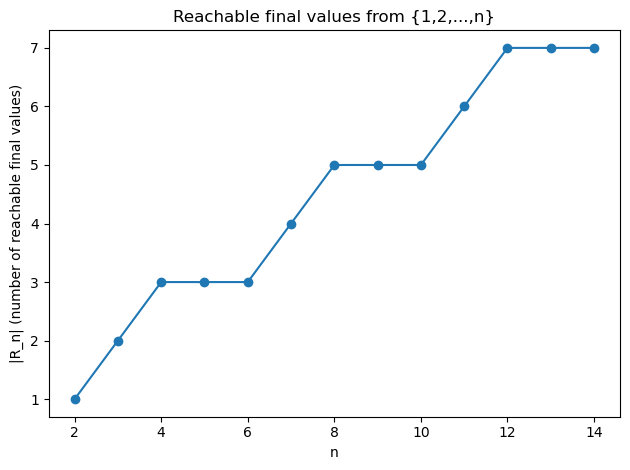

In [5]:

import matplotlib.pyplot as plt

def compute_Rn_sizes(n_max: int = 14):

    ns = list(range(2, n_max + 1))
    sizes = []
    for n in ns:
        reachable = R_n(n)        
        sizes.append(len(reachable))
        print(f"n={n:2d}  |R_n|={len(reachable):2d}  R_n={sorted(reachable)}")
    return ns, sizes

if __name__ == "__main__":

    n_max = 14
    ns, sizes = compute_Rn_sizes(n_max=n_max)

    plt.figure()
    plt.plot(ns, sizes, marker="o")
    plt.xlabel("n")
    plt.ylabel("|R_n| (number of reachable final values)")
    plt.title("Reachable final values from {1,2,...,n}")
    plt.tight_layout()
    plt.savefig("Rn_vs_n.png", dpi=300)
    plt.show()


In [2]:
from collections import deque
from functools import lru_cache
from itertools import combinations

def canonical(state):
    return tuple(sorted(state))

def apply_move(state, i, j):
    a, b = state[i], state[j]
    d = abs(a - b)
    new_list = list(state)
    del new_list[j]
    del new_list[i]
    new_list.append(d)
    return canonical(new_list), (a, b, d)

def bfs_to_target(final_target, start_state):
    start_state = canonical(start_state)
    q = deque([start_state])
    parent = {start_state: None}       
    parent_move = {start_state: None} 

    while q:
        state = q.popleft()
        if len(state) == 1 and state[0] == final_target:
            moves = []
            cur = state
            while parent[cur] is not None:
                moves.append(parent_move[cur])
                cur = parent[cur]
            moves.reverse()
            return True, moves

        k = len(state)
        for i, j in combinations(range(k), 2):
            nxt, mv = apply_move(state, i, j)
            if nxt not in parent:
                parent[nxt] = state
                parent_move[nxt] = mv
                q.append(nxt)

    return False, []

@lru_cache(maxsize=None)
def reachable_zero_from_state(state):
    found, _ = bfs_to_target(0, state)
    return found

def verify_zero_isolation_method(max_n=14, print_witness=False):
    failures = []

    for n in range(1, max_n + 1):
        total_sum = n * (n + 1) // 2
        required_parity = total_sum % 2

        admissible_targets = [t for t in range(0, n + 1) if (t % 2) == required_parity]

        base = tuple(range(1, n + 1))

        for t in admissible_targets:
            if t == 0:
                ok, moves = bfs_to_target(0, base)
                if not ok:
                    failures.append((n, t))
                elif print_witness:
                    print(f"\n[n={n}, t=0] Witness: reduce {list(base)} to 0")
                    for step, (a, b, d) in enumerate(moves, 1):
                        print(f"  {step:2d}. ({a},{b}) -> {d}")
            else:
                rest = list(base)
                rest.remove(t)
                rest = canonical(rest)

                ok, moves = bfs_to_target(0, rest)
                if not ok:
                    failures.append((n, t))
                elif print_witness:
                    print(f"\n[n={n}, t={t}] Witness:")
                    print(f"  Keep aside {t}. Reduce rest {list(rest)} to 0, then (t,0)->t.")
                    for step, (a, b, d) in enumerate(moves, 1):
                        print(f"  {step:2d}. ({a},{b}) -> {d}")
                    print(f"  {len(moves)+1:2d}. ({t},0) -> {t}")

    if failures:
        print("FAILED for the following (n,t) pairs:")
        for n, t in failures:
            print(f"  n={n}, t={t}")
        return False
    else:
        print(f"SUCCESS: zero-isolation method verified for all admissible targets for n <= {max_n}.")
        return True

if __name__ == "__main__":
    verify_zero_isolation_method(max_n=14, print_witness=True)


[n=3, t=0] Witness: reduce [1, 2, 3] to 0
   1. (1,3) -> 2
   2. (2,2) -> 0

[n=4, t=0] Witness: reduce [1, 2, 3, 4] to 0
   1. (1,2) -> 1
   2. (1,4) -> 3
   3. (3,3) -> 0

[n=4, t=2] Witness:
  Keep aside 2. Reduce rest [1, 3, 4] to 0, then (t,0)->t.
   1. (1,4) -> 3
   2. (3,3) -> 0
   3. (2,0) -> 2

[n=4, t=4] Witness:
  Keep aside 4. Reduce rest [1, 2, 3] to 0, then (t,0)->t.
   1. (1,3) -> 2
   2. (2,2) -> 0
   3. (4,0) -> 4

[n=5, t=1] Witness:
  Keep aside 1. Reduce rest [2, 3, 4, 5] to 0, then (t,0)->t.
   1. (2,3) -> 1
   2. (1,5) -> 4
   3. (4,4) -> 0
   4. (1,0) -> 1

[n=5, t=3] Witness:
  Keep aside 3. Reduce rest [1, 2, 4, 5] to 0, then (t,0)->t.
   1. (1,2) -> 1
   2. (1,5) -> 4
   3. (4,4) -> 0
   4. (3,0) -> 3

[n=5, t=5] Witness:
  Keep aside 5. Reduce rest [1, 2, 3, 4] to 0, then (t,0)->t.
   1. (1,2) -> 1
   2. (1,4) -> 3
   3. (3,3) -> 0
   4. (5,0) -> 5

[n=6, t=1] Witness:
  Keep aside 1. Reduce rest [2, 3, 4, 5, 6] to 0, then (t,0)->t.
   1. (2,4) -> 2
   2. (2


[n=12, t=8] Witness:
  Keep aside 8. Reduce rest [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12] to 0, then (t,0)->t.
   1. (1,2) -> 1
   2. (1,3) -> 2
   3. (2,4) -> 2
   4. (2,5) -> 3
   5. (3,6) -> 3
   6. (3,7) -> 4
   7. (4,11) -> 7
   8. (7,9) -> 2
   9. (2,12) -> 10
  10. (10,10) -> 0
  11. (8,0) -> 8

[n=12, t=10] Witness:
  Keep aside 10. Reduce rest [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12] to 0, then (t,0)->t.
   1. (1,2) -> 1
   2. (1,3) -> 2
   3. (2,4) -> 2
   4. (2,5) -> 3
   5. (3,7) -> 4
   6. (4,6) -> 2
   7. (2,9) -> 7
   8. (7,8) -> 1
   9. (1,12) -> 11
  10. (11,11) -> 0
  11. (10,0) -> 10

[n=12, t=12] Witness:
  Keep aside 12. Reduce rest [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] to 0, then (t,0)->t.
   1. (1,2) -> 1
   2. (1,3) -> 2
   3. (2,4) -> 2
   4. (2,5) -> 3
   5. (3,6) -> 3
   6. (3,7) -> 4
   7. (4,10) -> 6
   8. (6,8) -> 2
   9. (2,11) -> 9
  10. (9,9) -> 0
  11. (12,0) -> 12

[n=13, t=1] Witness:
  Keep aside 1. Reduce rest [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] to 0, t